In [1]:
import numpy as np
import pandas as pd
import scipy.spatial
from scipy.sparse import lil_matrix, csgraph
import geopandas as gpd
import matplotlib.pyplot as plt

import datetime
from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Read data

In [2]:
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
nhd_path = '/home/akagi/Documents/Data/GIS/NHD_H_Texas_State_GDB/NHD_H_Texas_State_GDB.gdb'
nhf_subbasins = gpd.read_file(nhf_path, layer='divides')
nhd_flowlines = gpd.read_file(nhd_path, layer=18)

/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


# Clip to study area

In [3]:
xmin, ymin, xmax, ymax = nhf_subbasins.to_crs(nhd_flowlines.crs).total_bounds
nhd_flowlines = nhd_flowlines.cx[xmin:xmax, ymin:ymax]
nhd_flowlines = nhd_flowlines.reset_index(drop=True)
geom_array = nhd_flowlines.geometry

In [4]:
# Ensure multilinestrings are actually linestrings
assert max(geom_array.apply(lambda x: len(x.geoms)).values) == 1

# Create and query spatial index of start and end points of flowlines

In [5]:
coords = geom_array.apply(lambda x: x.geoms[0]).apply(lambda y: y.coords.xy)
x = coords.str[0]
y = coords.str[1]
x0, x1 = x.str[0], x.str[-1]
y0, y1 = y.str[0], y.str[-1]
p0 = np.column_stack([x0.values, y0.values])
p1 = np.column_stack([x1.values, y1.values])
xy = np.column_stack([np.concatenate(x.values), np.concatenate(y.values)])

p0_indices = np.asarray([0] + x.str.len().cumsum().values.tolist()[:-1])
p1_indices = (x.str.len().cumsum() - 1).values
radius = 4
threshold = 0.

tree = scipy.spatial.KDTree(xy)
arr_lens = x.apply(lambda x: len(x))
point_indices = np.repeat(arr_lens.index.values, arr_lens.values)
start_dists, start_indices = tree.query(p0, k=radius)
end_dists, end_indices = tree.query(p1, k=radius)

# Connect upstream ends based on proximity

In [6]:
starts = point_indices[start_indices]
upstream = {}
upstream_points = {}
upstream_dists = {}
upstream_failed = []

for i in range(p0.shape[0]):
    upstream[i] = []
    upstream_points[i] = []
    upstream_dists[i] = []
    for j in range(radius):
        if start_dists[i,j] <= threshold:
            if starts[i,j] != i:
                upstream[i].append(starts[i,j])
                upstream_points[i].append(start_indices[i,j])
                upstream_dists[i].append(start_dists[i,j])
    if not upstream[i]:
        upstream_failed.append(i)

In [7]:
print(f'{len(upstream_failed)} upstream connections unmatched')

53153 upstream connections unmatched


# Connect downstream ends based on proximity

In [8]:
ends = point_indices[end_indices]
downstream = {}
downstream_points = {}
downstream_dists = {}
downstream_failed = []

for i in range(p1.shape[0]):
    downstream[i] = []
    downstream_points[i] = []
    downstream_dists[i] = []
    for j in range(radius):
        if end_dists[i,j] <= threshold:
            if ends[i, j] != i:
                downstream[i].append(ends[i,j])
                downstream_points[i].append(end_indices[i,j])
                downstream_dists[i].append(end_dists[i,j])
    if not downstream[i]:
        downstream_failed.append(i)

In [9]:
print(f'{len(downstream_failed)} downstream connections unmatched')

1193 downstream connections unmatched


# Check connectivity

In [10]:
n = nhd_flowlines.shape[0]
adj = lil_matrix((n, n), dtype=int)
nodes = np.arange(n)
for i in nodes:
    j = upstream[i]
    k = downstream[i]
    if j:
        for jj in j:
            adj[i, jj] = 1
            adj[jj, i] = 1
    if k:
        for kk in k:
            adj[kk, i] = 1
            adj[i, kk] = 1

In [11]:
num_components, labels = csgraph.connected_components(adj,
                                                      directed=True,
                                                      connection='weak')

In [12]:
num_components

1240

# Create reach-to-reach mapping for Trinity

In [13]:
trinity_outlet = '93945390'
trinity_outlet_index = nhd_flowlines[nhd_flowlines['permanent_identifier'] == trinity_outlet].index.item()

nhd_flowlines['id'] = nhd_flowlines.index

In [14]:
dist, pred = csgraph.shortest_path(adj, return_predecessors=True, indices=trinity_outlet_index)

In [15]:
nhd_flowlines['to_id'] = [nhd_flowlines.loc[j, 'id'] if j != -9999 else nhd_flowlines.loc[i, 'id'] for i, j in zip(nodes, pred)]
nhd_flowlines['labels'] = labels

In [16]:
trinity = nhd_flowlines[nhd_flowlines['id'] != nhd_flowlines['to_id']]
trinity = pd.concat([trinity, nhd_flowlines.loc[[trinity_outlet_index]]], axis=0)

id_mapping = pd.Series(np.arange(len(trinity)), index=trinity['id'])
trinity.index = id_mapping.values
trinity['id'] = id_mapping.loc[trinity['id']].values
trinity['to_id'] = id_mapping.loc[trinity['to_id']].values

<Axes: >

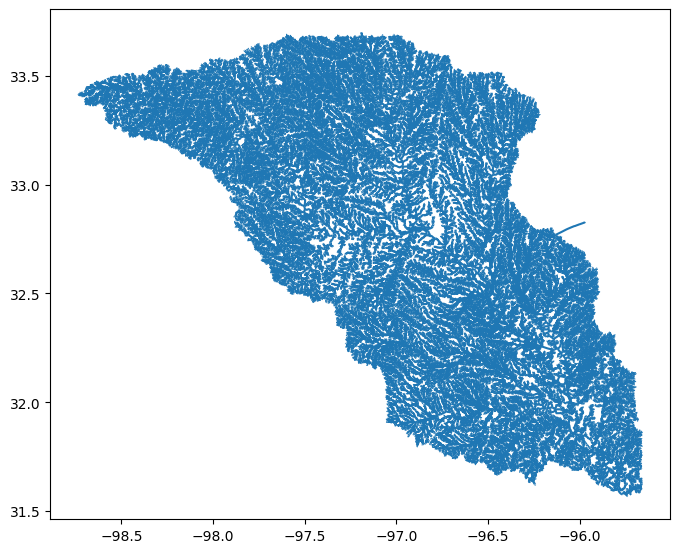

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
trinity.plot(column='labels', cmap='tab10', ax=ax)

# Prepare Muskingum model input data

In [18]:
name = 'trinity'
start_date = pd.to_datetime(datetime.datetime.utcnow(), utc=True)
timedelta = pd.to_timedelta(1, unit='h')
reach_ids = trinity['id'].astype(str).values
to_reach_ids = trinity['to_id'].fillna(-1).astype(int).astype(str).values

In [19]:
# Establish drainage network topology
reach_index = pd.Series(trinity.index.values, index=reach_ids)
startnodes = reach_index.reindex(reach_ids, fill_value=-1).values
endnodes = reach_index.reindex(to_reach_ids, fill_value=-1).values
self_loops = []
for i in range(len(startnodes)):
    if endnodes[i] == -1:
        self_loops.append(i)
        endnodes[i] = startnodes[i]

# Specify parameters
K = 3600 * np.ones(trinity.shape[0], dtype=np.float64)                     # Travel times [s]
X = 0.29 * np.ones(trinity.shape[0], dtype=np.float64)                     # Attenuation parameter [-]
o_t = 0. * np.ones(trinity.shape[0], dtype=np.float64)                     # Initial outflow from each reach [m^3/s]
dx = (1000 * trinity['SHAPE_Length']).values                                  # Reach lengths [m]

# Process flowpath geometries
linestring_geoms = trinity.geometry.apply(lambda x: x.geoms[0])            # Note: this flattens multilinestrings
paths = (linestring_geoms.apply(lambda x: [np.column_stack(x.xy)])
         .values.tolist())

# Apply initial flow to headwaters only
indegree = np.bincount(endnodes, minlength=len(startnodes))[startnodes]
o_t[indegree == 0] = 1.

# Package model instance data into dictionary

In [20]:
data = {
    'name' : name,
    'datetime' : start_date,
    'timedelta' : timedelta,
    'reach_ids' : reach_ids,
    'startnodes' : startnodes,
    'endnodes' : endnodes,
    'K' : K,
    'X' : X,
    'o_t' : o_t,
    'dx' : dx,
    'paths' : paths
}

# Instantiate Muskingum model

In [21]:
model = Muskingum(data)

# Plot domain

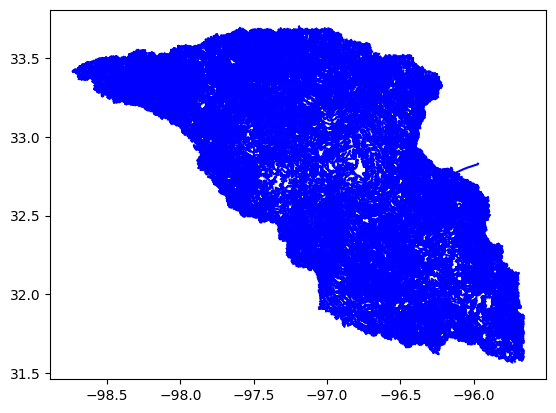

In [22]:
fig, ax = plt.subplots()
model.plot(ax=ax, c='b')

# Create precipitation forcing

In [23]:
n_steps = 24 * 7
date_range = pd.date_range(start=model.datetime + pd.to_timedelta('1h'), 
                           periods=n_steps, freq='1h', tz='utc')
# Note: precipitation forcing is zero for this test case
p_t = pd.DataFrame(0. * np.ones((n_steps, model.n)), index=date_range)
p_t.columns = model.reach_ids

# Run simulation over 7 days

In [24]:
model.init_states(o_t_next=o_t)

outputs = {}
outputs[model.datetime] = model.o_t_next

for state in model.simulate_iter(p_t):
    o_t_next = state.o_t_next
    outputs[state.datetime] = o_t_next
ref_outputs = pd.DataFrame.from_dict(outputs, orient='index')
ref_outputs.columns = model.reach_ids
ref_outputs.index = pd.to_datetime(ref_outputs.index, utc=True)

# Plot streamflow output

Text(0.5, 0, 'Time (h)')

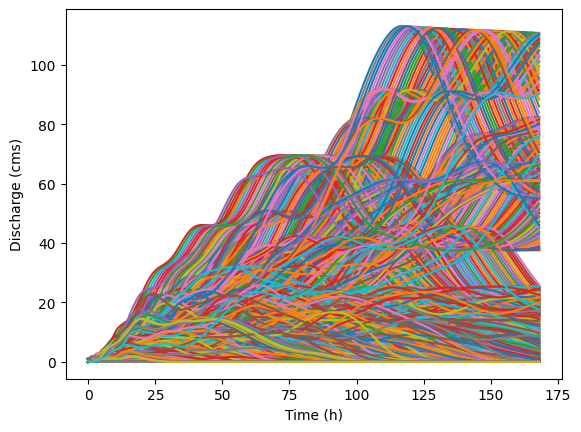

In [25]:
_ = plt.plot(ref_outputs.values)
plt.ylabel('Discharge (cms)')
plt.xlabel('Time (h)')

# Write discharge outputs to CSV file

In [26]:
ref_outputs.to_csv('../data/dfw_outputs_nhd_test.csv')

# Create model collection file

In [27]:
model_collection = ModelCollection([model], 'trinity_nhd')
model_collection.dump_model_collection('../data/trinity_nhd_muskingum.json')

# Write to file for inspection in GIS

In [28]:
trinity.to_file('../data/GIS/trinity_connectivity.shp')

/tmp/ipykernel_17352/455506307.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  trinity.to_file('../data/GIS/trinity_connectivity.shp')
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'permanent_identifier' to 'permanent_'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Field fdate create as date field, though DateTime requested.
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'wbarea_permanent_identifier' to 'wbarea_per'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'visibilityfilter' to 'visibility'
  ogr_write(
/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'SHAPE_Length' to 'S